# DenseNet121 Pretrained Model

In [15]:
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, Input, Flatten
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf

In [16]:
INPUT_SHAPE=(460, 460, 3)

In [17]:
# !pip install -q kagglehub

In [18]:
# import kagglehub

# path = kagglehub.dataset_download("mohamedhanyyy/chest-ctscan-images")

# print("Path to dataset files:", path)

In [19]:
# DATASET_PATH = '/kaggle/input/datasets/mohamedhanyyy/chest-ctscan-images'
DATASET_PATH = '/content/drive/MyDrive/Colab Notebooks/Chest Cancer Classification'

In [20]:
train_dataset = image_dataset_from_directory(
    f'{DATASET_PATH}/Data/train',
    color_mode='rgb',
    image_size=INPUT_SHAPE[:2],
    batch_size=8,
    shuffle=True
)

test_dataset = image_dataset_from_directory(
    f'{DATASET_PATH}/Data/test',
    color_mode='rgb',
    image_size=INPUT_SHAPE[:2],
    batch_size=8,
    shuffle=False
)

valid_dataset = image_dataset_from_directory(
    f'{DATASET_PATH}/Data/valid',
    color_mode='rgb',
    image_size=INPUT_SHAPE[:2],
    batch_size=8,
    shuffle=False
)

Found 613 files belonging to 4 classes.
Found 315 files belonging to 4 classes.
Found 72 files belonging to 4 classes.


In [21]:
class_names = train_dataset.class_names
class_names

['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib',
 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa',
 'normal',
 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']

In [22]:
print("Train:", train_dataset.class_names)
print("Valid:", valid_dataset.class_names)
print("Test :", test_dataset.class_names)

Train: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Valid: ['adenocarcinoma_left.lower.lobe_T2_N0_M0_Ib', 'large.cell.carcinoma_left.hilum_T2_N2_M0_IIIa', 'normal', 'squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa']
Test : ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']


In [23]:
# from tensorflow.keras import layers

# rescale = tf.keras.Sequential([
#   layers.Rescaling(1./255),
# ])

In [24]:
augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

In [25]:
base_model = DenseNet201(
    weights="imagenet",
    include_top=False,
    input_shape=INPUT_SHAPE,
    pooling='avg'
)

74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [26]:
# freeze all layer except conv5 layer
for layer in base_model.layers:
    if 'conv5' not in layer.name:
        layer.trainable = False

In [27]:
preprocess_input = tf.keras.applications.densenet.preprocess_input

preprocess = tf.keras.layers.Lambda(
    lambda x: preprocess_input(x)
)

In [28]:
train_dataset = train_dataset.cache()
valid_dataset = valid_dataset.cache()

train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)
valid_dataset = valid_dataset.prefetch(tf.data.AUTOTUNE)

In [29]:
# base_model.trainable = False

## CNN Model

In [41]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
model = tf.keras.models.Sequential([
    Input(shape=(460, 460, 3)),

    augmentation,

    preprocess,
    # rescale,


    base_model,

    # Flatten(),

    # tf.keras.layers.Dense(128, activation = 'relu',  kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    # # tf.keras.layers.BatchNormalization(),
    # # Dropout(0.3),

    # tf.keras.layers.Dense(128, activation = 'relu'),
    # tf.keras.layers.Dense(128, activation = 'relu'),
    # tf.keras.layers.Dense(128, activation = 'relu'),
    tf.keras.layers.BatchNormalization(),
    # Dropout(0.1),



    tf.keras.layers.Dense(4, activation="softmax")
])

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=0.00001,
    weight_decay=1e-6
)

model.compile(
      optimizer=optimizer,
      loss="sparse_categorical_crossentropy",
      metrics=["accuracy"]
)

history = model.fit(
    train_dataset,
    epochs=50,
    validation_data=valid_dataset,
    callbacks=[early_stopping]
)

Epoch 1/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 95s 495ms/step - accuracy: 0.5237 - loss: 1.0960 - val_accuracy: 0.4722 - val_loss: 1.1107
Epoch 2/50
77/77 ━━━━━━━━━━━━━━━━━━━━ 30s 385ms/step - accuracy: 0.8140 - loss: 0.5873 - val_accuracy: 0.6806 - val_loss: 0.8946
Epoch 3/50
 1/77 ━━━━━━━━━━━━━━━━━━━━ 14:53 12s/step - accuracy: 0.7500 - loss: 0.3159

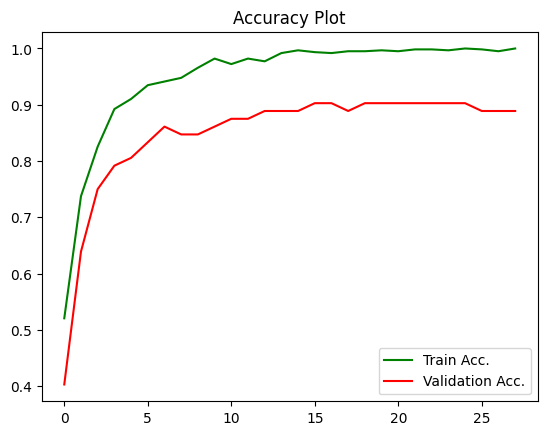

In [43]:
import matplotlib.pyplot as plt

plt.title('Accuracy Plot')

plt.plot(history.history['accuracy'], color='green', label='Train Acc.')
plt.plot(history.history['val_accuracy'], color='red', label='Validation Acc.')

plt.legend()
plt.show()

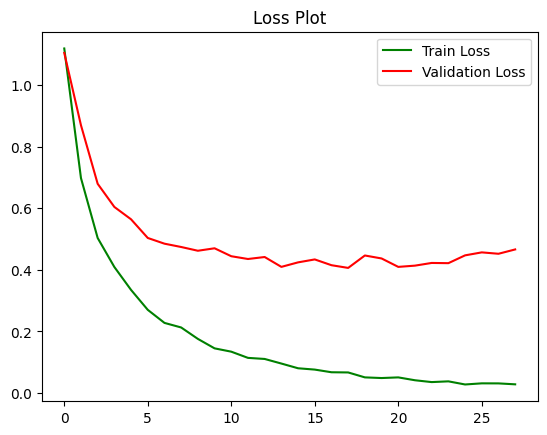

In [44]:
import matplotlib.pyplot as plt

plt.title('Loss Plot')

plt.plot(history.history['loss'], color='green', label='Train Loss')
plt.plot(history.history['val_loss'], color='red', label='Validation Loss')

plt.legend()
plt.show()

In [45]:
test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test accuracy:", test_accuracy)

40/40 ━━━━━━━━━━━━━━━━━━━━ 10s 252ms/step - accuracy: 0.8667 - loss: 0.4304
Test accuracy: 0.8666666746139526


In [47]:
model.save(f'{DATASET_PATH}/model_v2.keras')
print('Model Saved Succesfully')

Model Saved Succesfully


In [46]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

print(classification_report(
    y_true,
    y_pred,
    target_names=test_dataset.class_names
))

print(confusion_matrix(y_true, y_pred))

                         precision    recall  f1-score   support

         adenocarcinoma       0.88      0.80      0.84       120
   large.cell.carcinoma       0.77      0.96      0.85        51
                 normal       0.95      0.98      0.96        54
squamous.cell.carcinoma       0.87      0.83      0.85        90

               accuracy                           0.87       315
              macro avg       0.87      0.89      0.88       315
           weighted avg       0.87      0.87      0.87       315

[[96 12  1 11]
 [ 2 49  0  0]
 [ 1  0 53  0]
 [10  3  2 75]]


## Prediction


In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

image_path = "/content/drive/MyDrive/Colab Notebooks/Chest Cancer Classification/Data/test/adenocarcinoma/000112 (2).png"

img = load_img(
    image_path,
    target_size=(460, 460),
    color_mode="rgb"
)

img_array = img_to_array(img)

# Add batch dimension
img_array = np.expand_dims(img_array, axis=0)